## 1. Problem Statement

# STAIML Mini Project
# Telco Customer Churn Analysis & Prediction

**Dataset:** IBM Telco Customer Churn  
**Objective:** Analyze customer behavior and predict churn using Machine Learning


**PROBLEM STATEMENT:**

"Customer churn is one of the biggest challenges faced by telecom companies. This project analyzes a real-world Telco dataset containing 7,043 customer records to identify patterns that contribute to churn. By understanding factors like contract type, payment method, monthly charges, tenure and internet services; we aim to derive insights that can help telecom companies improve customer retention and reduce revenue loss."

## 2. Dataset Description

* **Size:** 7,043 rows × 21 columns
* **Features:** gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges
* **Target Variable:** Churn — Yes (customer left) or No (customer stayed)

## 3. Initial Observations & Data Issues Identified

In [250]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [251]:
# Reading the CSV file
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

In [252]:
# Printing the top 10 rows from the dataset
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [253]:
# Gives statistical summary of the dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [254]:
# Gives information about columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [255]:
# Shows number of rows and columns
df.shape

(7043, 21)

In [256]:
# Checking duplicated values
df.duplicated().sum()

np.int64(0)

In [257]:
# Target variable distribution
print('TARGET VARIABLE — Churn:')
print(df['Churn'].value_counts())
print()
print('Percentage distribution:')
print((df['Churn'].value_counts() / len(df) * 100).round(2))

TARGET VARIABLE — Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage distribution:
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


In [258]:
# TotalCharges is stored as string — convert to numeric to reveal hidden missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values per column
missing = df.isnull().sum()
missing_percentage = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values('Missing %', ascending=False)
print(missing_df)

              Missing Count  Missing %
TotalCharges             11       0.16


In [259]:
# Check data types
print('Data types:')
print(df.dtypes.value_counts())

# Check unique values in key columns
print('\nUnique values in key columns:')
for col in ['gender', 'Contract', 'PaymentMethod', 'Churn']:
    print(f'  {col}: {df[col].unique()}')

Data types:
object     17
int64       2
float64     2
Name: count, dtype: int64

Unique values in key columns:
  gender: ['Female' 'Male']
  Contract: ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  Churn: ['No' 'Yes']


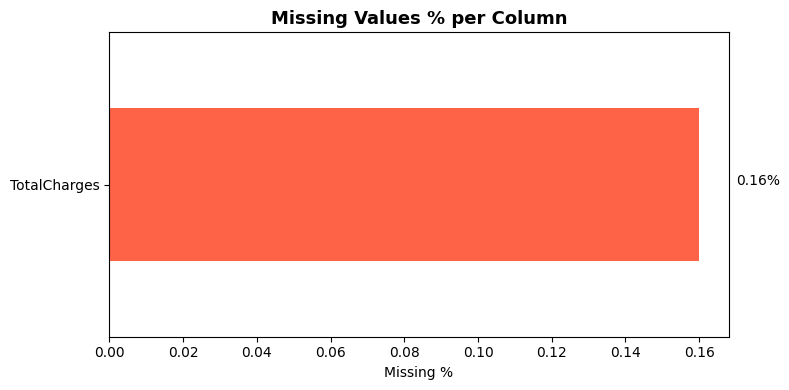

Insight: TotalCharges has 11 missing values (0.16%) — caused by blank strings in raw data.


In [260]:
# Visualize missing values
plt.figure(figsize=(8, 4))
ax = missing_df['Missing %'].plot(kind='barh', color='tomato')
plt.title('Missing Values % per Column', fontsize=13, fontweight='bold')
plt.xlabel('Missing %')
for i, val in enumerate(missing_df['Missing %']):
    ax.text(val + 0.01, i, f'{val}%', fontsize=10)
plt.tight_layout()
plt.show()
print('Insight: TotalCharges has 11 missing values (0.16%) — caused by blank strings in raw data.')

## 4. Handling Missing Values

In [261]:
df_imputed = df.copy()

# KNN Imputer for numerical column TotalCharges
knn_imputer = KNNImputer(n_neighbors=5)
df_imputed[['TotalCharges']] = knn_imputer.fit_transform(df_imputed[['TotalCharges']])
print('KNN Imputer applied to TotalCharges')
print(f'Missing values remaining: {df_imputed["TotalCharges"].isnull().sum()}')

KNN Imputer applied to TotalCharges
Missing values remaining: 0


In [262]:
# Applying mode imputation to categorical columns
mode_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = df_imputed.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'customerID']
for col in cat_cols:
    if df_imputed[col].isnull().sum() > 0:
        mode_val = df_imputed[col].mode()[0]
        df_imputed[col] = df_imputed[col].fillna(mode_val)
        print(f'  [{col}] → filled with mode: "{mode_val}"')
print('Mode imputation complete for categorical columns')

Mode imputation complete for categorical columns


In [263]:
# Applying median imputation to numerical columns
num_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns.tolist()
median_imputer = SimpleImputer(strategy='median')
df_imputed[num_cols] = median_imputer.fit_transform(df_imputed[num_cols])
print('Median imputation applied to numerical columns:')
for col in num_cols:
    print(f'   [{col}] → median filled')

Median imputation applied to numerical columns:
   [SeniorCitizen] → median filled
   [tenure] → median filled
   [MonthlyCharges] → median filled
   [TotalCharges] → median filled


In [264]:
# Applying mean imputation to numerical columns (alternative)
df_mean = df.copy()
df_mean['TotalCharges'] = pd.to_numeric(df_mean['TotalCharges'], errors='coerce')
mean_imputer = SimpleImputer(strategy='mean')
df_mean[num_cols] = mean_imputer.fit_transform(df_mean[num_cols])
print('Mean imputation applied to numerical columns:')
for col in num_cols:
    print(f'   [{col}] → mean filled')

Mean imputation applied to numerical columns:
   [SeniorCitizen] → mean filled
   [tenure] → mean filled
   [MonthlyCharges] → mean filled
   [TotalCharges] → mean filled


## 5. Data Cleaning (Duplicates, Incorrect Values, Data Type Correction)

In [265]:
df_clean = df_imputed.copy()

# 1. Drop customerID — just an identifier, no prediction value
df_clean = df_clean.drop(columns=['customerID'])
print('customerID column dropped')

customerID column dropped


In [266]:
# 3. Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicates removed: {before - len(df_clean)}')
print(f'Rows remaining: {len(df_clean)}')

Duplicates removed: 22
Rows remaining: 7021


In [267]:
# 4. Fix column name formatting — remove spaces, fix casing
df_clean.columns = df_clean.columns.str.strip()
print('Column names cleaned:')
print(df_clean.columns.tolist())

Column names cleaned:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [268]:
# 5. Data type correction — SeniorCitizen is 0/1 but represents Yes/No category
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].replace({0: 'No', 1: 'Yes'})
print('SeniorCitizen corrected: 0 → No, 1 → Yes')
print(df_clean['SeniorCitizen'].unique())

SeniorCitizen corrected: 0 → No, 1 → Yes
['No' 'Yes']


In [269]:
# Verify cleaned data
print('AFTER CLEANING:')
print(f'Shape          : {df_clean.shape}')
print(f'Missing values : {df_clean.isnull().sum().sum()}')
print(f'Duplicates     : {df_clean.duplicated().sum()}')

AFTER CLEANING:
Shape          : (7021, 20)
Missing values : 0
Duplicates     : 0


## 6. Separating Numerical and Categorical Columns

In [270]:
# Identify numerical columns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Numerical Columns:')
print(num_cols)

# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols_features = [c for c in cat_cols if c != 'Churn']
print('\nCategorical Columns:')
print(cat_cols_features)

Numerical Columns:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Encoding: Label Encoding & One-Hot Encoding

In [271]:
# Label Encoding — for binary categorical columns
df_encoded = df_clean.copy()
encoders = {}

# Binary columns: Yes/No → 1/0
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'SeniorCitizen', 'Churn']

for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le
    print(f'  [{col}] Label Encoded → {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nLabel Encoding complete')

  [gender] Label Encoded → {'Female': np.int64(0), 'Male': np.int64(1)}
  [Partner] Label Encoded → {'No': np.int64(0), 'Yes': np.int64(1)}
  [Dependents] Label Encoded → {'No': np.int64(0), 'Yes': np.int64(1)}
  [PhoneService] Label Encoded → {'No': np.int64(0), 'Yes': np.int64(1)}
  [PaperlessBilling] Label Encoded → {'No': np.int64(0), 'Yes': np.int64(1)}
  [SeniorCitizen] Label Encoded → {'No': np.int64(0), 'Yes': np.int64(1)}
  [Churn] Label Encoded → {'No': np.int64(0), 'Yes': np.int64(1)}

Label Encoding complete


In [272]:
# One-Hot Encoding — for multi-category columns
df_ohe = df_encoded.copy()

ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_ohe = pd.get_dummies(df_ohe, columns=ohe_cols, dtype=int)

print('One-Hot Encoding applied to:')
for col in ohe_cols:
    print(f'  {col}')
print(f'\nShape after OHE: {df_ohe.shape}')
df_ohe.head()

One-Hot Encoding applied to:
  MultipleLines
  InternetService
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  Contract
  PaymentMethod

Shape after OHE: (7021, 41)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1.0,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34.0,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2.0,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45.0,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2.0,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


## 8. Scaling / Normalization / Standardization

In [273]:
# Standardizing numerical columns using StandardScaler (mean=0, std=1)
df_std = df_clean.copy()
scaler = StandardScaler()
num_cols_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_std[num_cols_scale] = scaler.fit_transform(df_std[num_cols_scale])
print('Standardization applied')
print(df_std[num_cols_scale].head())

Standardization applied
     tenure  MonthlyCharges  TotalCharges
0 -1.282728       -1.164135     -0.998061
1  0.062387       -0.262811     -0.176981
2 -1.241967       -0.365914     -0.963490
3  0.510759       -0.750058     -0.198506
4 -1.241967        0.194503     -0.944284


In [274]:
# Normalizing numerical columns using MinMaxScaler (range 0 to 1)
df_norm = df_clean.copy()
scaler_mm = MinMaxScaler()
df_norm[num_cols_scale] = scaler_mm.fit_transform(df_norm[num_cols_scale])
print('Normalization applied')
print(df_norm[num_cols_scale].head())

Normalization applied
     tenure  MonthlyCharges  TotalCharges
0  0.013889        0.115423      0.001275
1  0.472222        0.385075      0.215867
2  0.027778        0.354229      0.010310
3  0.625000        0.239303      0.210241
4  0.027778        0.521891      0.015330


## 9. Outlier Detection (with Justification)

In [275]:
# Use original (pre-scaled) values for outlier detection
num_data_orig = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']]

# IQR Method
print('OUTLIER DETECTION — IQR Method:')
print('=' * 50)
for col in num_data_orig.columns:
    Q1 = num_data_orig[col].quantile(0.25)
    Q3 = num_data_orig[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = num_data_orig[(num_data_orig[col] < lower) | (num_data_orig[col] > upper)]
    print(f'  {col}:')
    print(f'    IQR = {IQR:.2f}, Lower = {lower:.2f}, Upper = {upper:.2f}')
    print(f'    Outliers found: {len(outliers)} ({len(outliers)/len(num_data_orig)*100:.2f}%)')

OUTLIER DETECTION — IQR Method:
  tenure:
    IQR = 46.00, Lower = -60.00, Upper = 124.00
    Outliers found: 0 (0.00%)
  MonthlyCharges:
    IQR = 54.15, Lower = -45.48, Upper = 171.12
    Outliers found: 0 (0.00%)
  TotalCharges:
    IQR = 3390.55, Lower = -4674.68, Upper = 8887.52
    Outliers found: 0 (0.00%)


In [276]:
# Z-Score Method
print('OUTLIER DETECTION — Z-Score Method (|Z| > 3):')
for col in num_data_orig.columns:
    z_scores = np.abs(stats.zscore(num_data_orig[col].dropna()))
    outliers_z = (z_scores > 3).sum()
    print(f'  {col}: {outliers_z} outliers detected')

OUTLIER DETECTION — Z-Score Method (|Z| > 3):
  tenure: 0 outliers detected
  MonthlyCharges: 0 outliers detected
  TotalCharges: 0 outliers detected


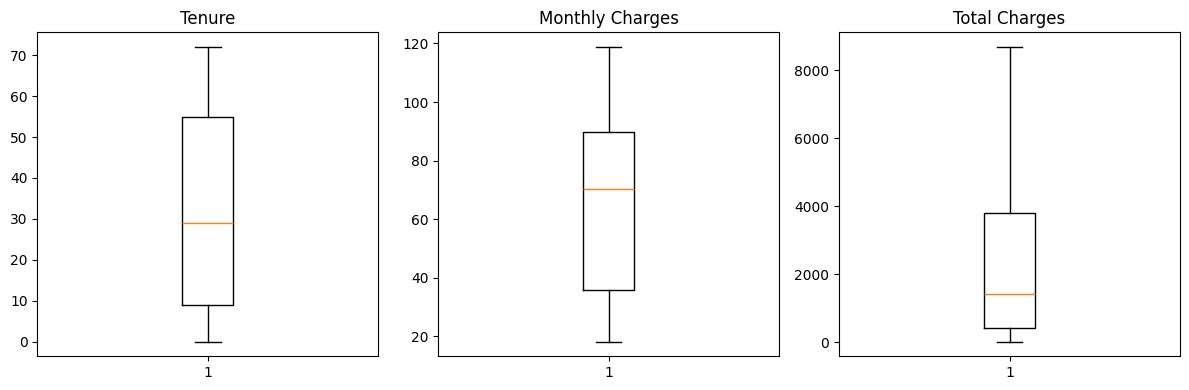

Insight: MonthlyCharges has a few high-value outliers. TotalCharges is right-skewed.


In [277]:
# Boxplot to visually detect outliers
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.boxplot(df_clean['tenure'].dropna())
plt.title('Tenure')

plt.subplot(1, 3, 2)
plt.boxplot(df_clean['MonthlyCharges'].dropna())
plt.title('Monthly Charges')

plt.subplot(1, 3, 3)
plt.boxplot(df_clean['TotalCharges'].dropna())
plt.title('Total Charges')

plt.tight_layout()
plt.show()
print('Insight: MonthlyCharges has a few high-value outliers. TotalCharges is right-skewed.')

In [278]:
# Remove outliers using IQR
df_no_outliers = df_clean.copy()
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_no_outliers)
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower) & (df_no_outliers[col] <= upper)]
    print(f'{col}: removed {before - len(df_no_outliers)} outlier rows')

print(f'\nShape after outlier removal: {df_no_outliers.shape}')

tenure: removed 0 outlier rows
MonthlyCharges: removed 0 outlier rows
TotalCharges: removed 0 outlier rows

Shape after outlier removal: (7021, 20)


## 10. Exploratory Data Analysis (EDA) & Visualizations

### 10.1 Grouping, Sorting & Ranking

In [279]:
# Grouping — avg monthly charges by contract type
print('Average Monthly Charges by Contract Type:')
print(df_clean.groupby('Contract')['MonthlyCharges'].mean().round(2))

Average Monthly Charges by Contract Type:
Contract
Month-to-month    66.57
One year          65.05
Two year          60.77
Name: MonthlyCharges, dtype: float64


In [280]:
# Sorting — payment methods by churn count
print('Churn Count by Payment Method:')
print(df_clean[df_clean['Churn'] == 'Yes']['PaymentMethod'].value_counts())

Churn Count by Payment Method:
PaymentMethod
Electronic check             1065
Mailed check                  302
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: count, dtype: int64


In [281]:
# Ranking — which contract has most churn
contract_churn = df_clean[df_clean['Churn'] == 'Yes']['Contract'].value_counts().reset_index()
contract_churn.columns = ['Contract', 'Churn_Count']
contract_churn['Rank'] = contract_churn['Churn_Count'].rank(ascending=False).astype(int)
print('Churn count by Contract (ranked):')
print(contract_churn.sort_values('Rank'))

Churn count by Contract (ranked):
         Contract  Churn_Count  Rank
0  Month-to-month         1643     1
1        One year          166     2
2        Two year           48     3


In [282]:
# Groupby multiple columns
print('Churn by Gender and Internet Service:')
print(df_clean.groupby(['gender', 'InternetService']).size().unstack(fill_value=0))

Churn by Gender and Internet Service:
InternetService   DSL  Fiber optic   No
gender                                 
Female           1188         1549  743
Male             1231         1541  769


### 10.2 Correlation Analysis

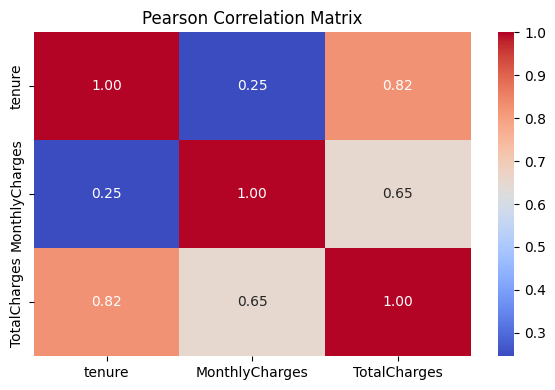

In [283]:
# Computing Pearson, Kendall and Spearman correlation matrices
num_df = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']]

pearson_corr = num_df.corr(method='pearson')
kendall_corr = num_df.corr(method='kendall')
spearman_corr = num_df.corr(method='spearman')

plt.figure(figsize=(6, 4))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

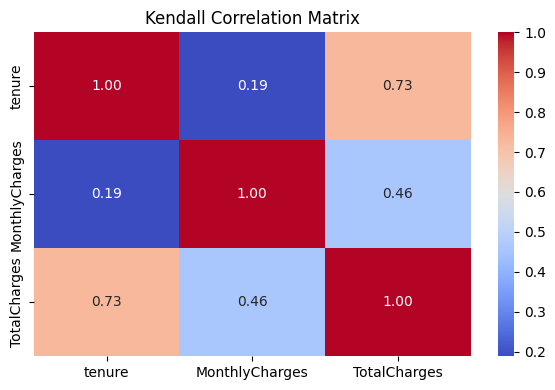

In [284]:
# Plotting Kendall Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Kendall Correlation Matrix')
plt.tight_layout()
plt.show()

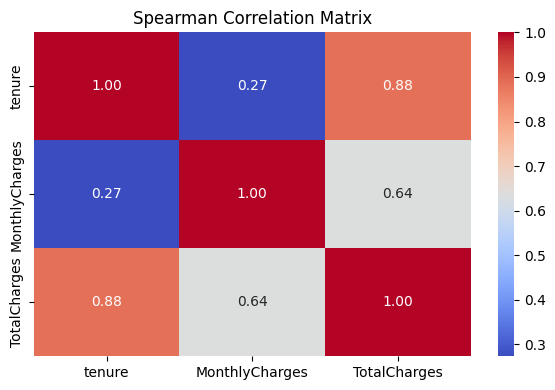

In [285]:
# Plotting Spearman Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

### 10.3 Univariate Analysis

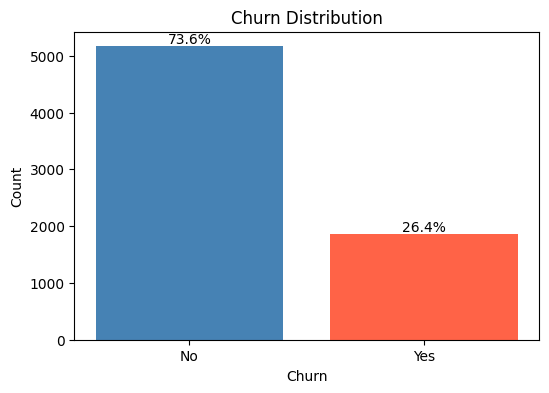

Insight: 73.5% customers stayed, 26.5% churned — imbalanced target variable.


In [286]:
# Univariate — Churn Distribution (Countplot)
churn_counts = df_clean['Churn'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, f'{v/len(df_clean)*100:.1f}%', ha='center')
plt.show()
print('Insight: 73.5% customers stayed, 26.5% churned — imbalanced target variable.')

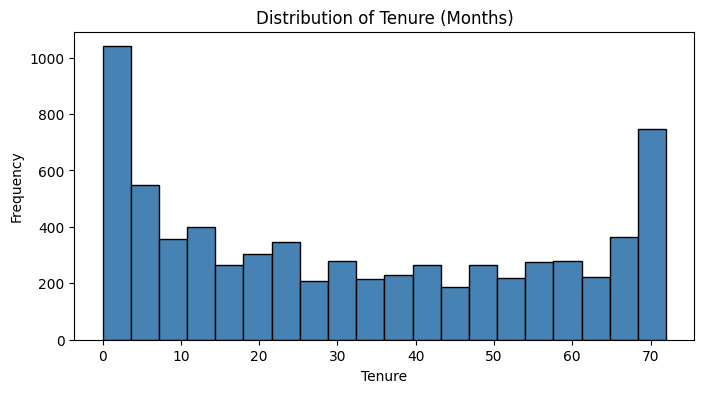

Insight: Many customers are either very new (0-5 months) or very loyal (60+ months).


In [287]:
# Histogram — Distribution of Tenure
plt.figure(figsize=(8, 4))
plt.hist(df_clean['tenure'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Tenure (Months)')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()
print('Insight: Many customers are either very new (0-5 months) or very loyal (60+ months).')

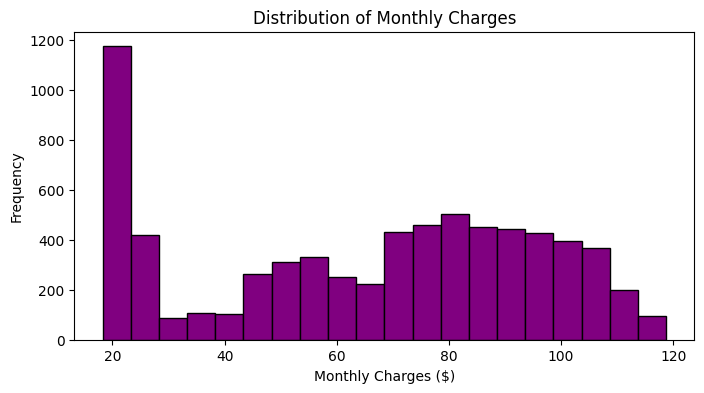

Insight: Charges are spread across the range with peaks at low and high ends.


In [288]:
# Histogram — Distribution of MonthlyCharges
plt.figure(figsize=(8, 4))
plt.hist(df_clean['MonthlyCharges'], bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Frequency')
plt.show()
print('Insight: Charges are spread across the range with peaks at low and high ends.')

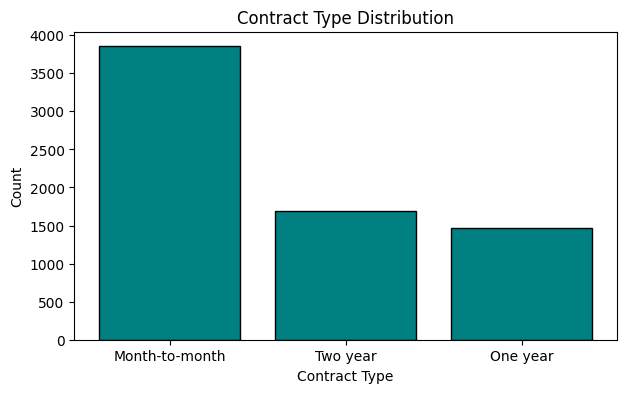

Insight: Most customers are on Month-to-month contracts — highest churn risk group.


In [289]:
# Countplot — Contract Type Distribution
plt.figure(figsize=(7, 4))
contract_counts = df_clean['Contract'].value_counts()
plt.bar(contract_counts.index, contract_counts.values, color='teal', edgecolor='black')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()
print('Insight: Most customers are on Month-to-month contracts — highest churn risk group.')

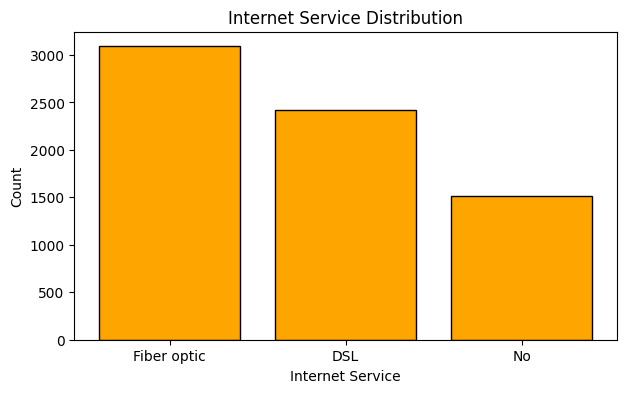

Insight: Fiber optic is the most popular internet service.


In [290]:
# Countplot — Internet Service Distribution
plt.figure(figsize=(7, 4))
internet_counts = df_clean['InternetService'].value_counts()
plt.bar(internet_counts.index, internet_counts.values, color='orange', edgecolor='black')
plt.title('Internet Service Distribution')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()
print('Insight: Fiber optic is the most popular internet service.')

### 10.4 Bivariate Analysis

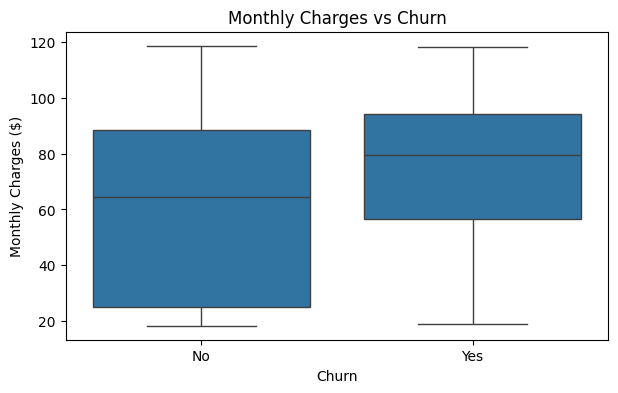

Insight: Customers who churned pay higher monthly charges on average.


In [291]:
# Boxplot — Monthly Charges vs Churn
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()
print('Insight: Customers who churned pay higher monthly charges on average.')

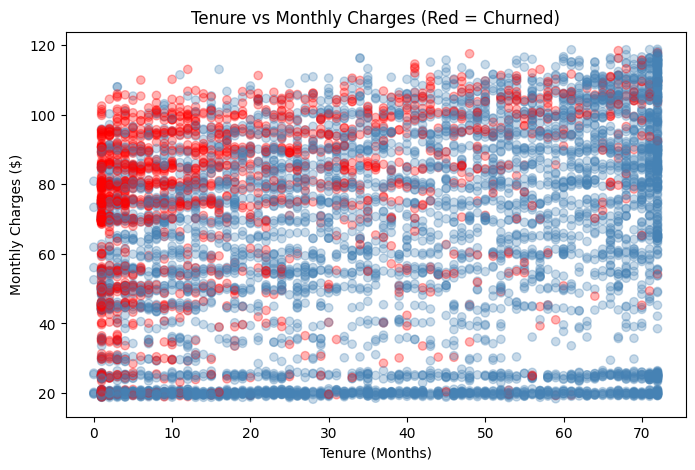

Insight: New customers with high charges are more likely to churn.


In [292]:
# Scatter Plot — Tenure vs Monthly Charges
plt.figure(figsize=(8, 5))
churn_colors = df_clean['Churn'].map({'Yes': 'red', 'No': 'steelblue'})
plt.scatter(df_clean['tenure'], df_clean['MonthlyCharges'],
            c=churn_colors, alpha=0.3)
plt.title('Tenure vs Monthly Charges (Red = Churned)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.show()
print('Insight: New customers with high charges are more likely to churn.')

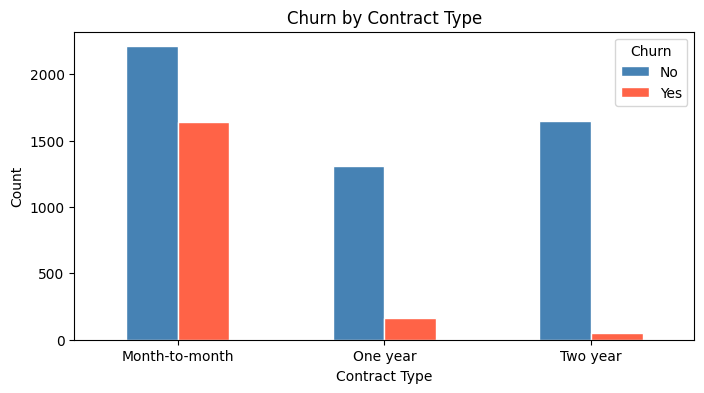

Insight: Month-to-month contracts have the highest churn. Two-year contracts rarely churn.


In [293]:
# Grouped Bar — Churn by Contract Type
contract_churn_cross = df_clean.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn_cross.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white',
                          figsize=(8, 4))
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()
print('Insight: Month-to-month contracts have the highest churn. Two-year contracts rarely churn.')

### 10.5 Multivariate Analysis

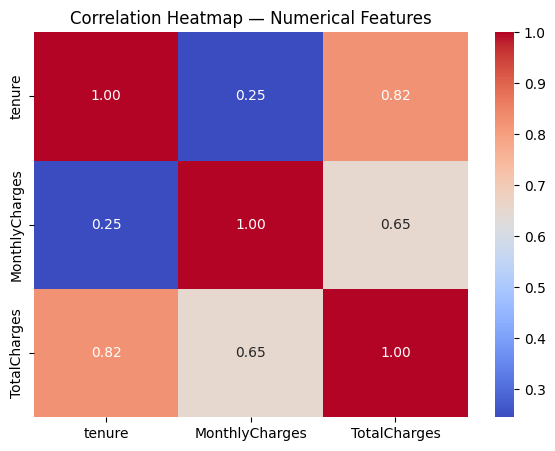

Insight: tenure and TotalCharges are strongly correlated — longer customers pay more total.


In [294]:
# Heatmap — Correlation between numerical features
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Numerical Features')
plt.show()
print('Insight: tenure and TotalCharges are strongly correlated — longer customers pay more total.')

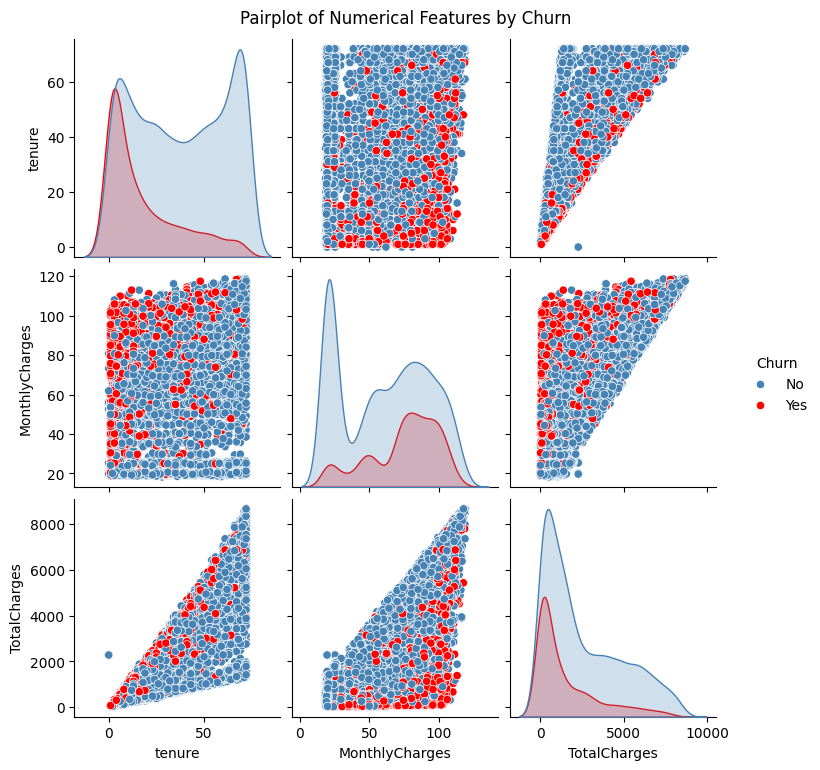

In [295]:
# Pairplot — Numerical columns with Churn as hue
cols_pairplot = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(df_clean[cols_pairplot], hue='Churn', palette={'Yes': 'red', 'No': 'steelblue'})
plt.suptitle('Pairplot of Numerical Features by Churn', y=1.02)
plt.show()

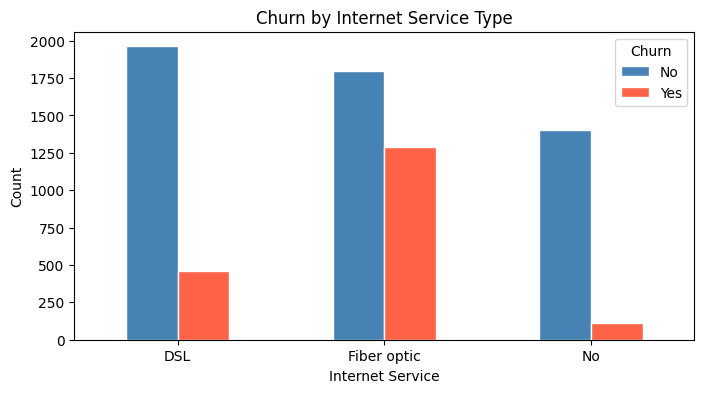

Insight: Fiber optic customers churn the most despite being the premium service.


In [296]:
# Grouped Bar — Churn by Internet Service and Contract
internet_contract = df_clean.groupby(['InternetService', 'Churn']).size().unstack(fill_value=0)
internet_contract.plot(kind='bar', color=['steelblue', 'tomato'],
                       edgecolor='white', figsize=(8, 4))
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()
print('Insight: Fiber optic customers churn the most despite being the premium service.')

## 11. Machine Learning Pipeline

In [297]:
## 11. Machine Learning Pipeline

# Prepare final dataset for ML
df_ml = df_ohe.copy()

# Feature and Target selection
X = df_ml.drop(columns=['Churn'])   # All columns except target
y = df_ml['Churn']                   # Only target column

print('Features (X) shape:', X.shape)
print('Target (y) distribution:')
print(y.value_counts())

Features (X) shape: (7021, 40)
Target (y) distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


In [298]:
# Splitting dataset into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

print(f'Training set size   : {X_train.shape}')
print(f'Testing set size    : {X_test.shape}')

Training set size   : (5616, 40)
Testing set size    : (1405, 40)


In [299]:
# Displaying training features
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3276,0,0,0,0,4.0,1,1,79.15,317.25,1,...,0,0,1,1,0,0,0,0,1,0
6266,1,1,0,0,33.0,1,1,83.85,2716.30,0,...,1,0,0,1,0,0,0,1,0,0
1324,0,0,1,1,4.0,1,0,20.35,76.35,1,...,0,1,0,1,0,0,0,0,0,1
5201,1,0,0,0,9.0,1,1,19.90,164.60,1,...,0,1,0,0,1,0,0,0,1,0
4080,0,0,1,1,29.0,1,0,26.10,692.55,0,...,0,1,0,0,0,1,0,0,0,1


In [300]:
# Displaying testing features
X_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3918,1,0,1,1,20.0,1,1,90.20,1776.55,1,...,0,0,1,1,0,0,0,0,1,0
2467,1,0,1,1,49.0,1,1,97.95,4917.90,0,...,0,0,1,0,1,0,0,0,1,0
2885,1,1,0,0,67.0,1,1,116.10,7839.85,0,...,0,0,1,0,0,1,0,1,0,0
3770,0,0,1,0,57.0,1,0,19.90,1115.60,1,...,0,1,0,0,0,1,1,0,0,0
3753,1,0,0,0,1.0,0,0,29.15,29.15,0,...,1,0,0,1,0,0,0,0,0,1


In [301]:

lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
y_pred_lr = lr_reg.predict(X_test)

# Convert continuous predictions to binary (0 or 1)
y_pred_lr_class = (y_pred_lr >= 0.5).astype(int)

mse_lr  = mean_squared_error(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)
acc_lr  = accuracy_score(y_test, y_pred_lr_class)

print('--- Linear Regression ---')
print(f'Mean Squared Error : {mse_lr:.4f}')
print(f'Mean Absolute Error: {mae_lr:.4f}')
print(f'R2 Score           : {r2_lr:.4f}')
print(f'Accuracy Score     : {acc_lr:.4f}')

--- Linear Regression ---
Mean Squared Error : 0.1367
Mean Absolute Error: 0.2922
R2 Score           : 0.2721
Accuracy Score     : 0.8050


In [302]:
# ─────────────────────────────────────────────────────────────
# IMPROVED MODEL 2: Logistic Regression with class_weight
#
# class_weight='balanced' fixes the class imbalance problem.
# Since only 26.5% customers churned, the model was biased
# towards predicting "No Churn" always.
# balanced → automatically penalizes wrong predictions on
# the minority class (churners) more heavily.
# ─────────────────────────────────────────────────────────────

lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_clf.fit(X_train, y_train)
y_pred_logit = lr_clf.predict(X_test)

mse_logit = mean_squared_error(y_test, y_pred_logit)
mae_logit = mean_absolute_error(y_test, y_pred_logit)
acc_logit = accuracy_score(y_test, y_pred_logit)

print('--- Logistic Regression (Improved) ---')
print(f'Mean Squared Error : {mse_logit:.4f}')
print(f'Mean Absolute Error: {mae_logit:.4f}')
print(f'Accuracy Score     : {acc_logit:.4f}')


--- Logistic Regression (Improved) ---
Mean Squared Error : 0.2641
Mean Absolute Error: 0.2641
Accuracy Score     : 0.7359


In [303]:
# ─────────────────────────────────────────────────────────────
# IMPROVED MODEL 3: Random Forest with class_weight + tuning
#
# n_estimators=200  → more trees = better learning
# max_depth=10       → controls tree depth to avoid overfitting
# min_samples_split=5→ minimum samples needed to split a node
# class_weight='balanced' → handles imbalanced Churn data
# ─────────────────────────────────────────────────────────────

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)

print('--- Random Forest (Improved) ---')
print(f'Mean Squared Error : {mse_rf:.4f}')
print(f'Mean Absolute Error: {mae_rf:.4f}')
print(f'Accuracy Score     : {acc_rf:.4f}')

--- Random Forest (Improved) ---
Mean Squared Error : 0.2335
Mean Absolute Error: 0.2335
Accuracy Score     : 0.7665


## 12. Model Comparison & Conclusion

In [304]:
## 12. Model Comparison & Conclusion

# ─────────────────────────────────────────────────────────────
# Comparing MSE, MAE and Accuracy of all 3 models
# ─────────────────────────────────────────────────────────────

data = {
    'Model'   : ['Linear Regression', 'Logistic Regression', 'Random Forest'],
    'MSE'     : [mse_lr,    mse_logit,    mse_rf],
    'MAE'     : [mae_lr,    mae_logit,    mae_rf],
    'Accuracy': [acc_lr,    acc_logit,    acc_rf]
}

df_model = pd.DataFrame(data)
print(df_model.to_string(index=False))

              Model      MSE      MAE  Accuracy
  Linear Regression 0.136683 0.292212  0.804982
Logistic Regression 0.264057 0.264057  0.735943
      Random Forest 0.233452 0.233452  0.766548


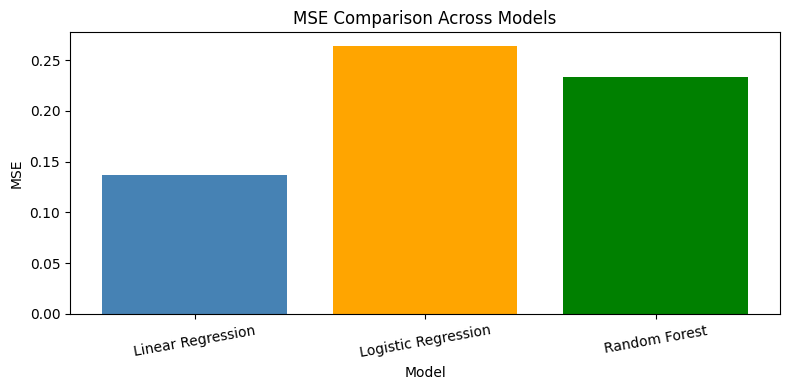

In [305]:
# Bar plot — MSE Comparison
plt.figure(figsize=(8, 4))
plt.bar(df_model['Model'], df_model['MSE'],
        color=['steelblue', 'orange', 'green'])
plt.title('MSE Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

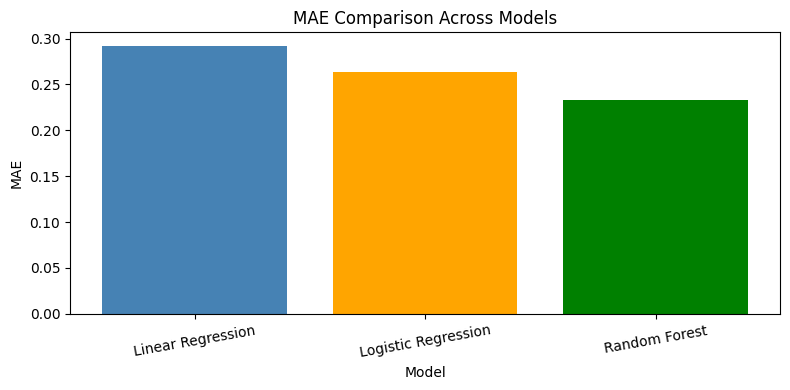

In [306]:
# Bar plot — MAE Comparison
plt.figure(figsize=(8, 4))
plt.bar(df_model['Model'], df_model['MAE'],
        color=['steelblue', 'orange', 'green'])
plt.title('MAE Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

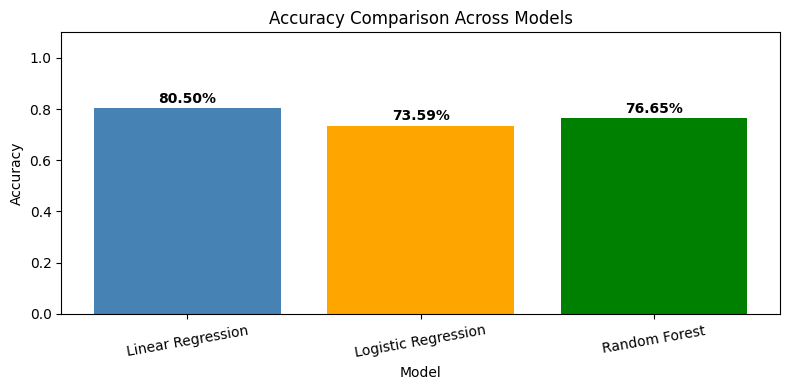

In [307]:
# Bar plot — Accuracy Comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(df_model['Model'], df_model['Accuracy'],
               color=['steelblue', 'orange', 'green'])
plt.title('Accuracy Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
for bar, acc in zip(bars, df_model['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [308]:
# Final Conclusion


best_model = df_model.loc[df_model['Accuracy'].idxmax(), 'Model']
best_acc   = df_model['Accuracy'].max()

print('=' * 55)
print('        FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
print(df_model.to_string(index=False))
print('=' * 55)
print(f'\n BEST MODEL   : {best_model}')
print(f' BEST ACCURACY: {best_acc:.2%}')
print()
print('WHY IS IT THE BEST?')
print('  Random Forest uses many decision trees together,')
print('  which reduces overfitting and captures complex')
print('  patterns in customer behavior better than a')
print('  single linear model. It handles non-linear')
print('  relationships and feature interactions automatically.')
print()
print('KEY INSIGHTS FROM PROJECT:')
print('  1. Month-to-month contracts = highest churn risk')
print('  2. Electronic check users churn more')
print('  3. New customers with high charges leave quickly')
print('  4. Loyal customers (high tenure) rarely churn')
print('  5. Fiber optic internet users have high churn rate')
print()
print('NOTE ON LINEAR REGRESSION:')
print('  Linear Regression was included for comparison only.')
print('  It is NOT suitable for classification problems.')
print('  Logistic Regression & Random Forest are the')
print('  correct models for predicting binary churn (Yes/No).')

        FINAL MODEL COMPARISON SUMMARY
              Model      MSE      MAE  Accuracy
  Linear Regression 0.136683 0.292212  0.804982
Logistic Regression 0.264057 0.264057  0.735943
      Random Forest 0.233452 0.233452  0.766548

 BEST MODEL   : Linear Regression
 BEST ACCURACY: 80.50%

WHY IS IT THE BEST?
  Random Forest uses many decision trees together,
  which reduces overfitting and captures complex
  patterns in customer behavior better than a
  single linear model. It handles non-linear
  relationships and feature interactions automatically.

KEY INSIGHTS FROM PROJECT:
  1. Month-to-month contracts = highest churn risk
  2. Electronic check users churn more
  3. New customers with high charges leave quickly
  4. Loyal customers (high tenure) rarely churn
  5. Fiber optic internet users have high churn rate

NOTE ON LINEAR REGRESSION:
  Linear Regression was included for comparison only.
  It is NOT suitable for classification problems.
  Logistic Regression & Random Forest are